# Hands on Semantic Segmentation with U-Net

In this lab we use models implemented in [segmentation_models](https://github.com/qubvel/segmentation_models) library and Tensorflow.

In [1]:
!pip install -q tensorflow==2.18.0
!pip install -q keras==3.5.0
!pip install -U -q segmentation-models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.7 MB/s eta 0:00:00


In [2]:
import tensorflow.keras
import numpy as np
import os
from IPython.display import Image, display
from tensorflow.keras.preprocessing.image import load_img
import PIL
from PIL import ImageOps
import cv2
import matplotlib.pyplot as plt


## Dataset

Fist, we download the dataset [Oxford-IIIT](https://www.robots.ox.ac.uk/~vgg/data/pets/) pet dataset.
![](https://www.robots.ox.ac.uk/~vgg/data/pets/pet_annotations.jpg)


In [3]:
!curl -LO https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!curl -LO https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   340  100   340    0     0    443      0 --:--:-- --:--:-- --:--:--   447
100  755M  100  755M    0     0  20.1M      0  0:00:37  0:00:37 --:--:-- 22.1M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   345  100   345    0     0    368      0 --:--:-- --:--:-- --:--:--   368
100 18.2M  100 18.2M    0     0  5639k      0  0:00:03  0:00:03 --:--:-- 9751k


load each image and its corresponding semantic mask.
Each mask has 3 labels:
- **0** for the Pet
- **1** for the Background
- **2** for the Border between the pet and the background

In [4]:
input_dir = "images/"
target_dir = "annotations/trimaps/"

img_size = (160, 160)
num_classes = 3
batch_size = 32

input_img_paths = sorted(
    [
        os.path.join(input_dir, fname)
        for fname in os.listdir(input_dir)
        if fname.endswith(".jpg")
    ]
)
target_img_paths = sorted(
    [
        os.path.join(target_dir, fname)
        for fname in os.listdir(target_dir)
        if fname.endswith(".png") and not fname.startswith(".")
    ]
)

print("Number of samples:", len(input_img_paths))

for input_path, target_path in zip(input_img_paths[:10], target_img_paths[:10]):
    print(input_path, "|", target_path)

Number of samples: 7390
images/Abyssinian_1.jpg | annotations/trimaps/Abyssinian_1.png
images/Abyssinian_10.jpg | annotations/trimaps/Abyssinian_10.png
images/Abyssinian_100.jpg | annotations/trimaps/Abyssinian_100.png
images/Abyssinian_101.jpg | annotations/trimaps/Abyssinian_101.png
images/Abyssinian_102.jpg | annotations/trimaps/Abyssinian_102.png
images/Abyssinian_103.jpg | annotations/trimaps/Abyssinian_103.png
images/Abyssinian_104.jpg | annotations/trimaps/Abyssinian_104.png
images/Abyssinian_105.jpg | annotations/trimaps/Abyssinian_105.png
images/Abyssinian_106.jpg | annotations/trimaps/Abyssinian_106.png
images/Abyssinian_107.jpg | annotations/trimaps/Abyssinian_107.png


Let us visualize some sample of the dataset

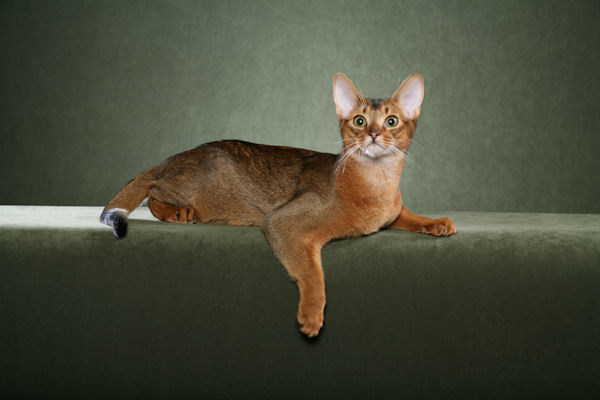

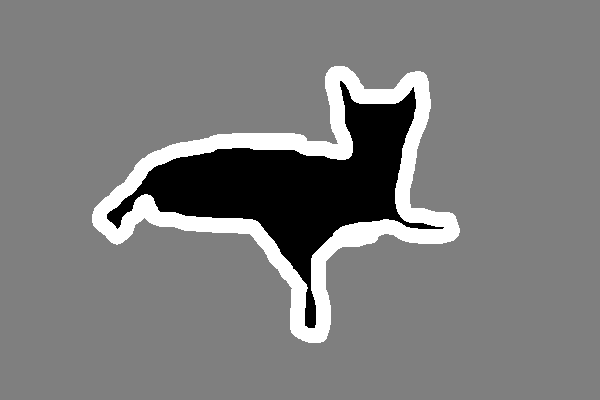

[0 1 2]


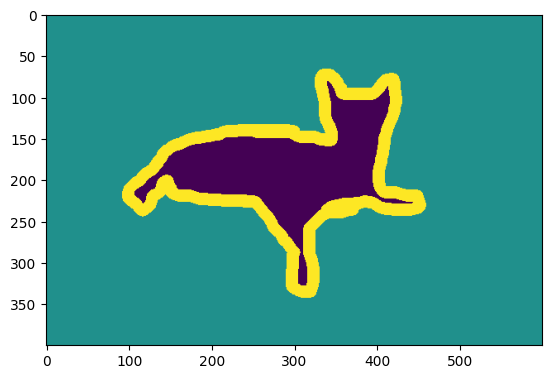

In [5]:
# Display input image #7
display(Image(filename=input_img_paths[0]))

# Display auto-contrast version of corresponding target (per-pixel categories)
img = PIL.ImageOps.autocontrast(load_img(target_img_paths[0]))
display(img)
a = cv2.imread(target_img_paths[0])-1
print(np.unique(a))

plt.imshow(a[:,:,0])

We will now read our images, and build two different sets of data:
1. Training set, made up of 500 samples;
2. Testing set, made up of 50 samples.

The training set will be further divided into training and validation, with a hold-out approach.
We first resize the images and the masks to have the same shape.

In [6]:
from tensorflow import keras
import cv2
import tensorflow as tf
import numpy as np

x = np.zeros((500,128,128,3), dtype="float32")
y = np.zeros((500,128,128,3), dtype="int32")

for j in range(0,500):
  img = cv2.imread(input_img_paths[j])
  img2 = cv2.imread(target_img_paths[j])
  try:
    img = cv2.resize(img,(128,128))
    img2=cv2.resize(img2,(128,128))
    x[j] = img
    y[j] = img2
  except:
    print(j)

136


Image 136 will not be resized correctly

In [7]:
x_test = np.zeros((50,128,128,3), dtype="float32")
y_test = np.zeros((50,128,128,3), dtype="int32")

for j in range(500,550):
  img = cv2.imread(input_img_paths[j])
  img2 = cv2.imread(target_img_paths[j])
  try:
    img = cv2.resize(img,(128,128))
    img2=cv2.resize(img2,(128,128))
    x_test[j-500] = img
    y_test[j-500] = img2
  except:
    print(j)

Normalize the images and the masks to have values between 0 and 1

In [8]:
# Normalize the data
x = x / 255.0

y = y[:, :, :, 0] - 1
y_test = y_test[:, :, :, 0] - 1

y = tf.keras.utils.to_categorical(y, num_classes=3)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=3)

**Exercise 1**

Write the code to implement (from scratch) a Unet architecture, and evaluate it on the Oxford-IIIT pet dataset.

*   First, build a function conv_block(x, n_filters) that builds two convolutional layers, with n_filters.
* Let's use a filter size 3x3

In [9]:
def double_conv_block(x, n_filters):
  #code here
  x = tf.keras.layers.Conv2D(filters=n_filters, kernel_size=(3,3), padding='same', activation="relu")(x)
  x = tf.keras.layers.Conv2D(filters=n_filters, kernel_size=(3,3), padding='same', activation="relu")(x)

  return x



*   Now, we define a function down_sample_block(x) that performs one step of our Unet:
1. Two convolutional layers (use function built in previous point)
2. Max pooling;



In [10]:
def downsample_block(x, n_filters):
   #code here
   conv = double_conv_block(x, n_filters)
   pool = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), padding='same')(conv)

   return conv, pool

It is now the moment of upsample blocks.


*   Write a function upsample_block(x,features,filters), where features is the input you want to merge as in the Unet architecture.
*   Let's use kernel size of 3, and stride of 2 (we want to double the size of our features) in this block
* use layers.concatenate to merge features and the current map



In [11]:
def upsample_block(x, conv_features, n_filters):
   #code here
   x = tf.keras.layers.Conv2DTranspose(filters=n_filters, kernel_size=(3,3), strides=(2,2), padding='same')(x)
   x = tf.keras.layers.Concatenate()([x, conv_features])
   x = double_conv_block(x, n_filters)

   return x

Now we build the Unet, following the original architecture

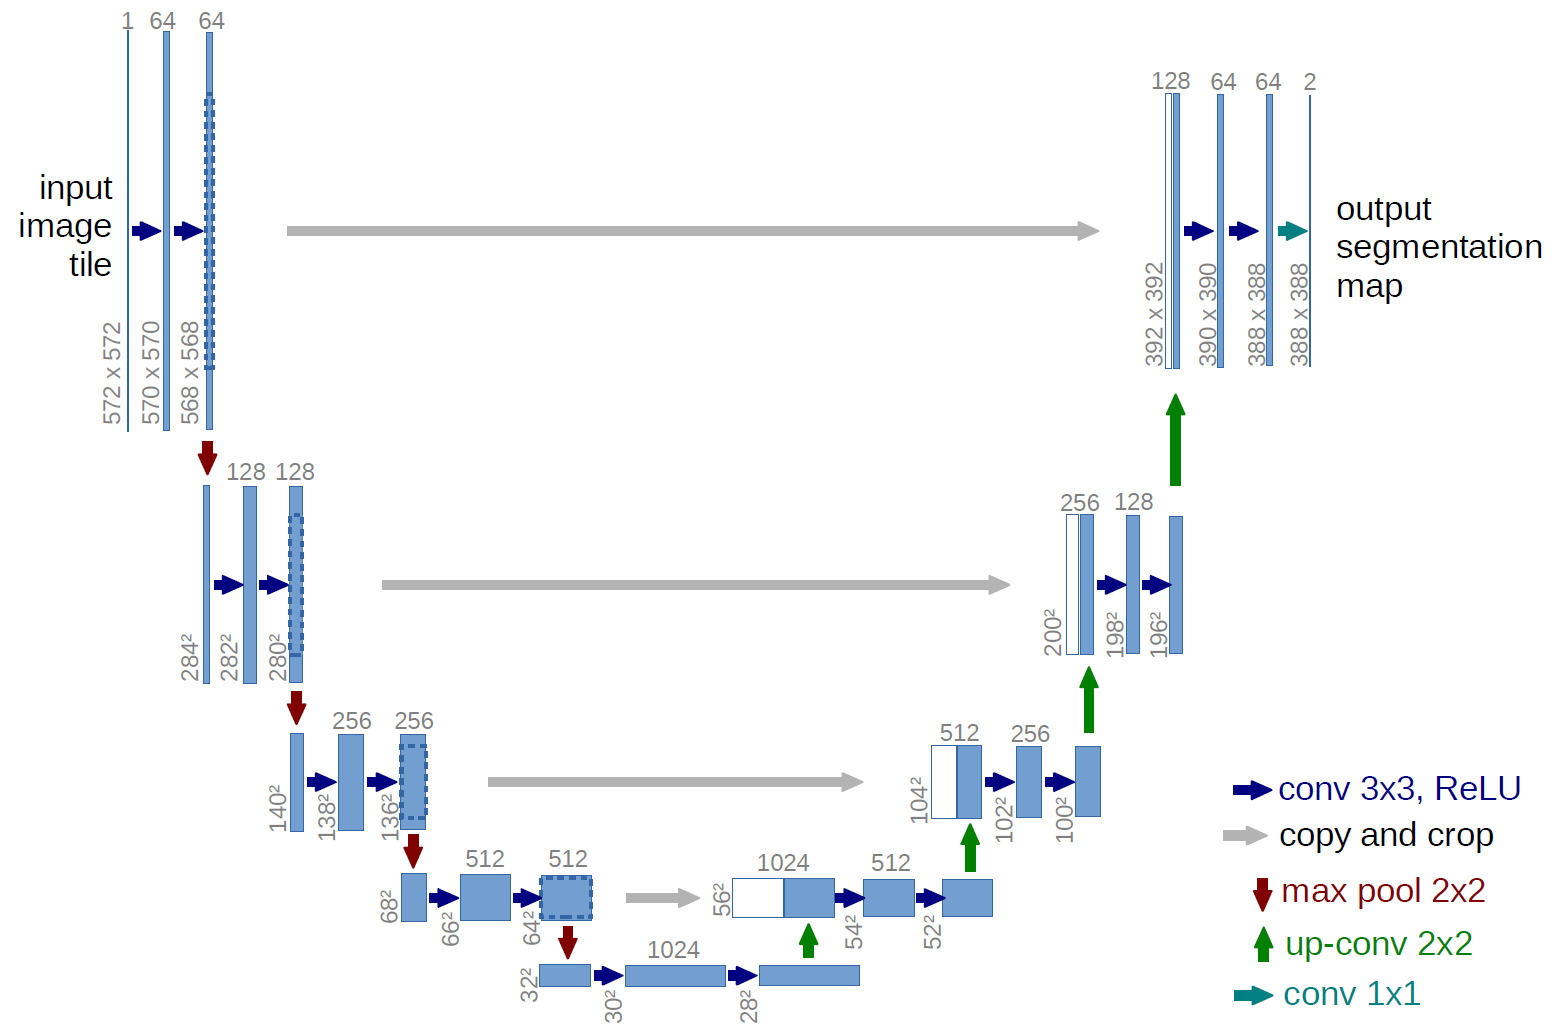

In [12]:
def Unet():
   # inputs
   inputs = tf.keras.layers.Input(shape=(128,128,3))
   # encoder: contracting path - downsample

   #code here
   c1, u1 = downsample_block(inputs, 64)
   c2, u2 = downsample_block(u1, 128)
   c3, u3 = downsample_block(u2, 256)
   c4, u4 = downsample_block(u3, 512)

   # 5 - bottleneck
   #code here
   u5 = double_conv_block(u4, 1024)

   # decoder: expanding path - upsample
   # code here
   u6 = upsample_block(u5, c4, 512)
   u7 = upsample_block(u6, c3, 256)
   u8 = upsample_block(u7, c2, 128)
   u9 = upsample_block(u8, c1, 64)

   # outputs
   outputs = tf.keras.layers.Conv2D(3, 1,  activation = "softmax")(u9)
   # unet model with Keras Functional API
   unet_model = tf.keras.Model(inputs, outputs, name="U-Net")
   return unet_model

Now we compile the model with segmentation_models categorical cross entropy, adam optimizer and accuracy as metrics.

help: loss=tf.keras.losses.categorical_crossentropy for the loss

In [20]:
# Create model instance
unet_model = Unet()

# Compile the model
unet_model.compile(loss=tensorflow.keras.losses.categorical_crossentropy, optimizer=tensorflow.keras.optimizers.Adam(learning_rate=0.001), metrics=['accuracy'])

Finally, we train our model

In [21]:
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
callbacks = [keras.callbacks.ModelCheckpoint("oxford_segmentation.keras", save_best_only=True)]

# Train the model, doing validation at the end of each epoch.
epochs = 10 #choose one value

np.random.seed(42)
tf.random.set_seed(42)

x_train, x_val, y_train, y_val = train_test_split(
    x, y,
    test_size=0.1,
    random_state=42,
    shuffle=True
)
#code for model training
unet_model.fit(x_train, y_train, epochs=epochs, validation_data=(x_val, y_val), callbacks=callbacks)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.4914 - loss: 1.0176 - val_accuracy: 0.6024 - val_loss: 0.9283
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.5788 - loss: 0.9279 - val_accuracy: 0.6024 - val_loss: 0.8611
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.5873 - loss: 0.8784 - val_accuracy: 0.6445 - val_loss: 0.7880
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 413ms/step - accuracy: 0.5498 - loss: 0.9559 - val_accuracy: 0.6024 - val_loss: 0.9037
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 407ms/step - accuracy: 0.5890 - loss: 0.8969 - val_accuracy: 0.6088 - val_loss: 0.8057
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 409ms/step - accuracy: 0.6184 - loss: 0.8446 - val_accuracy: 0.5936 - val_loss: 1.0114
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 415ms/step - accuracy: 0.5841 - loss: 0.9464 - val_accuracy: 0.6024 - val_loss: 0.8279
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 414ms/step - accuracy: 0.5959 - loss: 0.8482 - val_accuracy: 0.5

Let us visualize few of our predictions. Try a bunch of images in the test set.

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step


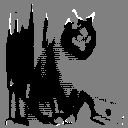

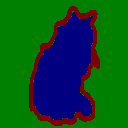

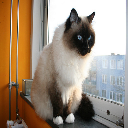

[0 1 2]


In [22]:
val_preds = unet_model.predict(x_test/255.0)
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
def display_mask(i):
    """Quick utility to display a model's prediction."""
    mask = np.argmax(val_preds[i], axis=-1)
    mask = np.expand_dims(mask, axis=-1)
    cv2_imshow(mask*128)
    cv2_imshow(y_test[i]*128)
    cv2_imshow(x_test[i])
    print(np.unique(mask))
# Display results for validation image #10
i = 0
# Display mask predicted by our model
display_mask(i)  # Note that the model only sees inputs at 150x150.

## Try to change few parameters in our defined Unet:

- add a dropout (after maxpooling) to the downsample block;
- Use more images for training;
- Change the learning rate;
- Change the optimizer.
Comments on how the results change.
If you want, you can change the metrics to IoU.

<h3>Adding a dropout</h3>

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 874ms/step - accuracy: 0.5359 - loss: 1.0882 - val_accuracy: 0.6024 - val_loss: 0.9481
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 416ms/step - accuracy: 0.5873 - loss: 0.9441 - val_accuracy: 0.6024 - val_loss: 0.8939
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 417ms/step - accuracy: 0.5873 - loss: 0.9214 - val_accuracy: 0.6024 - val_loss: 0.9290
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 420ms/step - accuracy: 0.5873 - loss: 0.9296 - val_accuracy: 0.6024 - val_loss: 0.8594
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 416ms/step - accuracy: 0.5873 - loss: 0.8975 - val_accuracy: 0.6024 - val_loss: 0.8213
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 417ms/step - accuracy: 0.5972 - loss: 0.8621 - val_accuracy: 0.6922 - val_loss: 0.7659
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 418ms/step - accuracy: 0.5870 - loss: 0.9357 - val_accuracy: 0.6024 - val_loss: 0.8828
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 423ms/step - accuracy: 0.5838 - loss: 0.8897 - val_accuracy

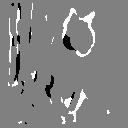

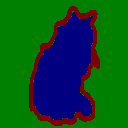

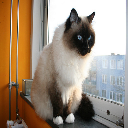

[0 1 2]


In [23]:
def UnetDropout():
   inputs = keras.layers.Input(shape=(128,128,3))

   c1, u1 = downsample_block(inputs, 64)
   c2, u2 = downsample_block(u1, 128)
   c3, u3 = downsample_block(u2, 256)
   c4, u4 = downsample_block(u3, 512)

   #Adding dropout
   u4bis = keras.layers.Dropout(0.5)(u4)

   u5 = double_conv_block(u4bis, 1024)

   u6 = upsample_block(u5, c4, 512)
   u7 = upsample_block(u6, c3, 256)
   u8 = upsample_block(u7, c2, 128)
   u9 = upsample_block(u8, c1, 64)

   outputs = keras.layers.Conv2D(3, 1,  activation = "softmax")(u9)
   unet_dropout_model = keras.Model(inputs, outputs, name="U-Net")
   return unet_dropout_model

unet_dropout_model = UnetDropout()
unet_dropout_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(learning_rate=0.001), metrics=['accuracy'])
unet_dropout_model.fit(x_train, y_train, epochs=epochs, validation_data=(x_val, y_val), callbacks=callbacks)

val_preds = unet_dropout_model.predict(x_test/255.0)
def display_mask(i):
    mask = np.argmax(val_preds[i], axis=-1)
    mask = np.expand_dims(mask, axis=-1)
    cv2_imshow(mask*128)
    cv2_imshow(y_test[i]*128)
    cv2_imshow(x_test[i])
    print(np.unique(mask))

display_mask(0)



<h3>Using more images</h3>

136
1042
1049
1070
1079
1095
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 37s 604ms/step - accuracy: 0.9420 - loss: 0.1457 - val_accuracy: 0.8239 - val_loss: 0.8457
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 435ms/step - accuracy: 0.9373 - loss: 0.1611 - val_accuracy: 0.8446 - val_loss: 0.6122
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 455ms/step - accuracy: 0.9415 - loss: 0.1478 - val_accuracy: 0.8457 - val_loss: 0.5949
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 448ms/step - accuracy: 0.9452 - loss: 0.1380 - val_accuracy: 0.8492 - val_loss: 0.6493
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 462ms/step - accuracy: 0.9464 - loss: 0.1342 - val_accuracy: 0.8464 - val_loss: 0.7186
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 447ms/step - accuracy: 0.9447 - loss: 0.1391 - val_accuracy: 0.8378 - val_loss: 0.6730
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 445ms/step - accuracy: 0.9424 - loss: 0.1453 - val_accuracy: 0.8261 - val_loss: 0.6301
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 447ms/step - accuracy: 0.9

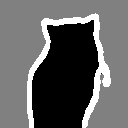

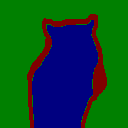

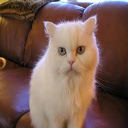

[0 1 2]


In [44]:
x2 = np.zeros((1500,128,128,3), dtype="float32")
y2 = np.zeros((1500,128,128,3), dtype="int32")

for j in range(0,1500):
  img = cv2.imread(input_img_paths[j])
  img2 = cv2.imread(target_img_paths[j])
  try:
    img = cv2.resize(img,(128,128))
    img2=cv2.resize(img2,(128,128))
    x2[j] = img
    y2[j] = img2
  except:
    print(j)

x_test2 = np.zeros((50,128,128,3), dtype="float32")
y_test2 = np.zeros((50,128,128,3), dtype="int32")

for j in range(1500,1550):
  img = cv2.imread(input_img_paths[j])
  img2 = cv2.imread(target_img_paths[j])
  try:
    img = cv2.resize(img,(128,128))
    img2=cv2.resize(img2,(128,128))
    x_test2[j-1500] = img
    y_test2[j-1500] = img2
  except:
    print(j)

x2 = x2 / 255.0
y2 = y2[:, :, :, 0] - 1
y_test2 = y_test2[:, :, :, 0] - 1
y2 = tf.keras.utils.to_categorical(y2, num_classes=3)
y_test2 = tf.keras.utils.to_categorical(y_test2, num_classes=3)

x_train2, x_val2, y_train2, y_val2 = train_test_split(
    x2, y2,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

unet_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(learning_rate=0.0001), metrics=['accuracy'])
unet_model.fit(x_train2, y_train2, epochs=epochs, validation_data=(x_val2, y_val2), callbacks=callbacks)

val_preds = unet_model.predict(x_test2/255.0)

def display_mask(i):
    mask = np.argmax(val_preds[i], axis=-1)
    mask = np.expand_dims(mask, axis=-1)
    cv2_imshow(mask*128)
    cv2_imshow(y_test2[i]*128)
    cv2_imshow(x_test2[i])
    print(np.unique(mask))

display_mask(12)



<h3>Changing the learning rate</h3>

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.7528 - loss: 0.6049 - val_accuracy: 0.8176 - val_loss: 0.4840
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.7858 - loss: 0.5348 - val_accuracy: 0.8203 - val_loss: 0.4737
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.7858 - loss: 0.5316 - val_accuracy: 0.8238 - val_loss: 0.4662
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.7897 - loss: 0.5235 - val_accuracy: 0.8244 - val_loss: 0.4617
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.7905 - loss: 0.5208 - val_accuracy: 0.8258 - val_loss: 0.4580
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.7922 - loss: 0.5169 - val_accuracy: 0.8266 - val_loss: 0.4553
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 944ms/step - accuracy: 0.7938 - loss: 0.5138 - val_accuracy: 0.8272 - val_loss: 0.4535
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7951 - loss: 0.5114 - val_accuracy: 0.8278 - val_lo

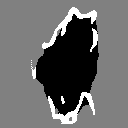

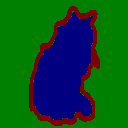

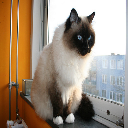

[0 1 2]


In [25]:
#increasing the learning rate
unet_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(learning_rate=0.00001), metrics=['accuracy'])
unet_model.fit(x_train, y_train, epochs=epochs, validation_data=(x_val, y_val), callbacks=callbacks)

val_preds = unet_model.predict(x_test/255.0, batch_size=x_test.shape[0])
def display_mask(i):
    mask = np.argmax(val_preds[i], axis=-1)
    mask = np.expand_dims(mask, axis=-1)
    cv2_imshow(mask*128)
    cv2_imshow(y_test[i]*128)
    cv2_imshow(x_test[i])
    print(np.unique(mask))

display_mask(0)

I added a batch_size to avoid a warning that appeared during execution

<h3>Changing the optimizer</h3>

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 853ms/step - accuracy: 0.8256 - loss: 0.4386 - val_accuracy: 0.8454 - val_loss: 0.3984
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8312 - loss: 0.4259 - val_accuracy: 0.8460 - val_loss: 0.3967
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 422ms/step - accuracy: 0.8297 - loss: 0.4280 - val_accuracy: 0.8463 - val_loss: 0.3983
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 421ms/step - accuracy: 0.8310 - loss: 0.4231 - val_accuracy: 0.8448 - val_loss: 0.3986
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 424ms/step - accuracy: 0.8327 - loss: 0.4238 - val_accuracy: 0.8442 - val_loss: 0.4003
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.8277 - loss: 0.4322 - val_accuracy: 0.8465 - val_loss: 0.3961
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.8264 - loss: 0.4362 - val_accuracy: 0.8466 - val_loss: 0.3958
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 418ms/step - accuracy: 0.8385 - loss: 0.4134 - val_accuracy: 0.842

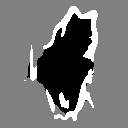

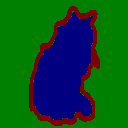

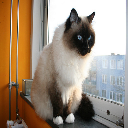

[0 1 2]


In [19]:
#using the Lion optimizer
unet_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.AdamW(learning_rate=0.00001, weight_decay=0.00001), metrics=['accuracy'])
unet_model.fit(x_train, y_train, epochs=epochs, validation_data=(x_val, y_val), callbacks=callbacks)

val_preds = unet_model.predict(x_test/255.0)
def display_mask(i):
    mask = np.argmax(val_preds[i], axis=-1)
    mask = np.expand_dims(mask, axis=-1)
    cv2_imshow(mask*128)
    cv2_imshow(y_test[i]*128)
    cv2_imshow(x_test[i])
    print(np.unique(mask))

display_mask(0)



<h3>Best solution</h3>



<h3></h3>